In [1]:
import pandas as pd
from PIL import Image
import io
import matplotlib.pyplot as plt

df = pd.read_parquet("train-00000-of-00001.parquet")
print(f"Всего изображений: {len(df)}")

Всего изображений: 160


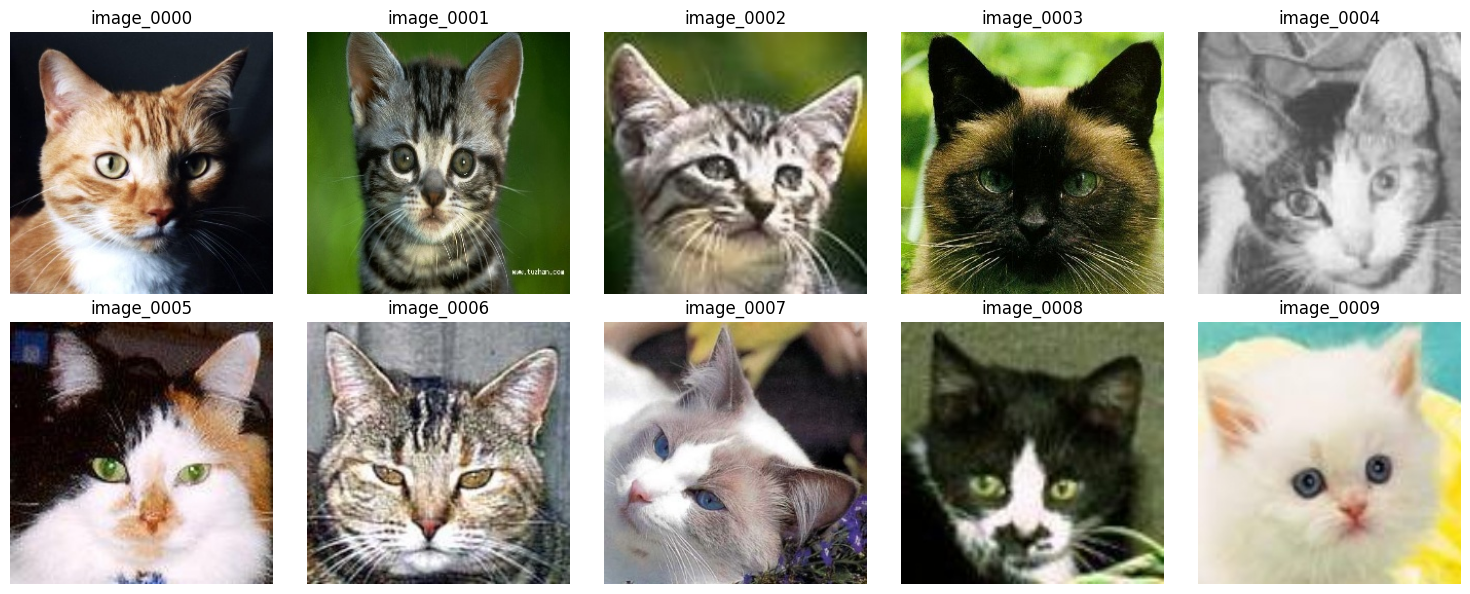

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = Image.open(io.BytesIO(df.iloc[i]['image']['bytes']))
    ax.imshow(img)
    ax.set_title(f"image_{i:04d}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
import os

os.makedirs("extracted_images", exist_ok=True)

for i in range(len(df)):
    img_bytes = df.iloc[i]['image']['bytes']
    with open(f"extracted_images/image_{i:04d}.jpg", "wb") as f:
        f.write(img_bytes)